# Ophalen van de data

In [ ]:
import requests
import csv
from datetime import datetime, timedelta
import time
import pandas as pd
import openmeteo_requests
import requests_cache
from retry_requests import retry

## Kijkcijfer data ophalen van laatste 10 jaar
Indien data mist wordt deze genegeerd. Alle andere data wordt volledig in een CSV file gestoken die later gefilterd en gecleaned kan worden

In [ ]:
start_date = datetime(2015, 2, 1)
end_date = datetime(2025, 3, 25)

# CSV-bestand aanmaken
with open('./data2/raw/kijkcijfer_data.csv', 'w') as csvfile:
  fieldnames = [
    'dateDiff', 'ranking', 'description', 'channel', 
    'startTime', 'rLength', 'rateInK', 'live'
  ]
  writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
  writer.writeheader()

  # Loop door elke dag
  current_date = start_date
  while current_date <= end_date:
    datum = f"{current_date.year}-{current_date.month}-{current_date.day}"
    url = f"https://api.cim.be/api/cim_tv_public_results_daily_views?dateDiff={datum}&reportType=north"
        
    try:
      response = requests.get(url)
      if response.status_code == 200:
        data = response.json()
        programma_lijst = data.get('hydra:member', [])
                
        for programma in programma_lijst:
          try:
            writer.writerow({
              'dateDiff': programma.get('dateDiff'),
              'ranking': programma.get('ranking'),
              'description': programma.get('description'),
              'channel': programma.get('channel'),
              'startTime': programma.get('startTime'),
              'rLength': programma.get('rLength'),
              'rateInK': programma.get('rateInK'),
              'live': programma.get('live')
            })
                        
          except Exception as e:
            print(f"Fout bij verwerken programma op {datum}: {e}")
                
        print(f"Success: {datum} ({len(programma_lijst)} programma's)")
      else:
        print(f"Geen data voor {datum} (HTTP {response.status_code})")
                
    except Exception as e:
      print(f"Fout bij ophalen {datum}: {e}")
        
    current_date += timedelta(days=1)
print("Alle data opgehaald!")

## Weerdata van laatste 10 jaar ophalen

In [ ]:
# Setup Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Geografisch middelpunt van Vlaanderen
latitude = 51.037861
longitude = 4.240528

# Laatste 10 jaar ophalen
end_date = datetime.now()
start_date = end_date - timedelta(days=365*10)

# API URL en parameters
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date.strftime('%Y-%m-%d'),
    "end_date": end_date.strftime('%Y-%m-%d'),
    "hourly": [
        "temperature_2m",
        "weathercode",
        "precipitation",
        "rain",
        "snowfall",
        "cloudcover",
        "windspeed_10m"
    ],
    "daily": [
        "weather_code",
        "wind_speed_10m_max",
        "sunrise",
        "sunset",
        "daylight_duration",
    ],
    "timezone": "Europe/Brussels",
    "temperature_unit": "celsius",
    "precipitation_unit": "mm",
    "windspeed_unit": "kmh"
}

# Data ophalen
response = requests_cache.CachedSession().get(url, params=params)
if response.status_code == 200:
    data = response.json()
    
    # Hourly data verwerken
    hourly = data["hourly"]
    hourly_df = pd.DataFrame({
        "time": pd.to_datetime(hourly["time"]),
        "temperature_2m": hourly["temperature_2m"],
        "weather_code": hourly["weathercode"],
        "precipitation": hourly["precipitation"],
        "rain": hourly["rain"],
        "snowfall": hourly["snowfall"],
        "cloudcover": hourly["cloudcover"],
        "windspeed_10m": hourly["windspeed_10m"]
    })
    
    # Daily dataframe
    daily = data["daily"]
    daily_df = pd.DataFrame({
        "date": pd.to_datetime(daily["time"]),
        "weather_code_daily": daily["weather_code"],
        "wind_speed_10m_max": daily["wind_speed_10m_max"],
        "sunrise": daily["sunrise"],
        "sunset": daily["sunset"],
        "daylight_duration": daily["daylight_duration"],
    })
    
    hourly_df["date"] = hourly_df["time"].dt.date
    
    # Maak date kolom om op te mergen
    hourly_df["date"] = pd.to_datetime(hourly_df["date"])
    daily_df["date"] = pd.to_datetime(daily_df["date"])
    
    # Merge hourly en daily data
    combined_df = hourly_df.merge(daily_df, on="date", how="left")
    
    combined_df["hour"] = combined_df["time"].dt.hour
    combined_df["day_of_week"] = combined_df["time"].dt.dayofweek
    combined_df["month"] = combined_df["time"].dt.month
    combined_df["year"] = combined_df["time"].dt.year
    
    # Opslaan als CSV-bestand
    combined_df.to_csv("./data2/raw/weerdata.csv", index=False)
    print("Succesvol opgeslagen als weerdata.csv")
else:
    print(f"Fout: {response.status_code}")
    print(response.text)

## Basic data cleaning van kijkcijferdata

In [ ]:
def clean_data(df):
    # Verwijder de kolom 'ranking', deze is nutteloos
    df.drop('ranking', axis=1, inplace=True)

    # Verwijder rijen met null waarden, deze zijn fout geregistreerd in de DB
    df.dropna(inplace=True)
        
    # Verwijder rijen waarvan tijdformaat nie overeenkomt met xx:xx:xx
    time_pattern = r'^\d{2}:\d{2}:\d{2}$'

    df = df[
        df["startTime"].str.match(time_pattern, na=False) & 
        df["rLength"].str.match(time_pattern, na=False)
    ].copy()

    # rLength omzetten naar seconden -> duration_sec
    # dateDiff omzetten naar datetime
    df['duration_sec'] = pd.to_timedelta(df['rLength']).dt.total_seconds()
    df['date'] = pd.to_datetime(df["dateDiff"]).dt.date

    # rateInK omzetten naar int -> viewers
    df['viewers'] = df['rateInK'].apply(lambda x: int(''.join(str(x).split('.'))))

    #startTime: 24:30:00 omzetten naar 00:30:00 en dateDiff 1 dag verhogen
    def fix_next_day(rij):
        time_parts = rij['startTime'].split(':')
        if int(time_parts[0]) >= 24:
            time_parts[0] = str(int(time_parts[0]) - 24).zfill(2)
            rij['date'] += timedelta(days=1)
        rij['startTime'] = ':'.join(time_parts)
        return rij

    df = df.apply(fix_next_day, axis=1)

    # timestamp kolom toevoegen op basis van dateDiff en startTime
    df['timestamp'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['startTime'].astype(str))

    # Live: boolean maken, of getal houden?? 28 > 7 > 1 > 0 heeft groter getal ook correlatie met kijkcijfer???
    # Beslissing: Live kolom laten als int

    # Hour year month day toevoegen
    df['hour'] = pd.to_datetime(df['startTime']).dt.hour
    df['year'] = pd.to_datetime(df['date']).dt.year
    df['month'] = pd.to_datetime(df['date']).dt.month
    df['day'] = pd.to_datetime(df['date']).dt.day

    # Onnodige kolommen verwijderen
    df.drop(['startTime', 'rLength', 'rateInK'], axis=1, inplace=True)

    df = df[['timestamp', 'date', 'year', 'month', 'day', 'hour', 'channel', 'description', 'duration_sec', 'live', 'viewers']]

    df.rename(columns={'description': 'program'}, inplace=True)

    return df

kijkcijfers = pd.read_csv('./data2/raw/kijkcijfer_data.csv')
kijkcijfers = clean_data(kijkcijfers)
kijkcijfers.to_csv('./data2/raw/kijkcijfer_clean.csv', index=False)

## Kijkcijferdata en weerdata mergen

In [ ]:
kijkcijfers = pd.read_csv('./data2/raw/kijkcijfer_clean.csv')
weerdata = pd.read_csv("./data2/raw/weerdata.csv")

kijkcijfers['date'] = pd.to_datetime(kijkcijfers['date'])

weerdata['time'] = pd.to_datetime(weerdata['time'])

weerdata['date'] = pd.to_datetime(weerdata['time'].dt.date)
weerdata['hour'] = weerdata['time'].dt.hour

merged_df = pd.merge(kijkcijfers, weerdata, on=['date', 'hour'], how='left')

merged_df.drop(columns=['date', 'time', 'month_y', 'year_y', 'live'], inplace=True)

merged_df.rename(columns={'month_x': 'month', 'year_x': 'year'}, inplace=True)

merged_df = merged_df[['timestamp', 'year', 'month', 'day', 'day_of_week', 'hour', 
                       'channel', 'program', 'duration_sec', 'viewers', 
                       'temperature_2m', 'weather_code', 'precipitation', 'rain', 
                       'snowfall', 'cloudcover', 'windspeed_10m', 'weather_code_daily', 
                       'wind_speed_10m_max', 'sunrise', 'sunset', 'daylight_duration']]

merged_df.to_csv('./data2/processed/kijkcijfers_weerdata.csv', index=False)
print("Data succesvol samengevoegd en opgeslagen als kijkcijfers_weerdata.csv")
merged_df.sample(3)

# Data cleaning

In [1]:
from datetime import datetime, timedelta
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
kijkcijfers = pd.read_csv('./data2/processed/kijkcijfers_weerdata.csv')
kijkcijfers['timestamp'] = pd.to_datetime(kijkcijfers['timestamp'])

Check basisinfo en check voor null-rijen

In [3]:
print(f"Aantal null-rows: \n{kijkcijfers.isnull().sum()}")
print(kijkcijfers.info())

Aantal null-rows: 
timestamp             0
year                  0
month                 0
day                   0
day_of_week           0
hour                  0
channel               0
program               0
duration_sec          0
viewers               0
temperature_2m        0
weather_code          0
precipitation         0
rain                  0
snowfall              0
cloudcover            0
windspeed_10m         0
weather_code_daily    0
wind_speed_10m_max    0
sunrise               0
sunset                0
daylight_duration     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61088 entries, 0 to 61087
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   timestamp           61088 non-null  datetime64[ns]
 1   year                61088 non-null  int64         
 2   month               61088 non-null  int64         
 3   day                 61088 non-null  int64     

Bekijk de waarden van viewers om te zien of er onrealistische outliers zijn:
- Alles lijkt oke te zijn => Geen speciale cleaning nodig

In [4]:
pd.options.display.float_format = '{:,.2f}'.format
kijkcijfers['viewers'].describe()

count      61,088.00
mean      446,035.63
std       277,972.24
min        15,887.00
25%       229,953.50
50%       360,184.50
75%       606,251.25
max     2,494,114.00
Name: viewers, dtype: float64

# Data Analyse

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

In [41]:
df = pd.read_csv('./data2/processed/kijkcijfers_weerdata.csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek # maandag=0, zondag=6

In [42]:
df.describe()

,timestamp,year,month,day,day_of_week,hour,duration_sec,viewers,temperature_2m,weather_code,precipitation,rain,snowfall,cloudcover,windspeed_10m,weather_code_daily,wind_speed_10m_max,daylight_duration
count,61088,"61,088.00","61,088.00","61,088.00","61,088.00","61,088.00","61,088.00","61,088.00","61,088.00","61,088.00","61,088.00","61,088.00","61,088.00","61,088.00","61,088.00","61,088.00","61,088.00","61,088.00"
mean,2020-12-23 22:01:16.086105088,"2,020.48",6.51,15.69,3.00,18.61,"2,681.87","446,035.63",12.59,11.56,0.10,0.09,0.00,67.28,13.96,36.50,19.97,"43,504.61"
min,2016-10-01 12:31:36,"2,016.00",1.00,1.00,0.00,0.00,900.00,"15,887.00",-6.30,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.30,"28,433.95"
25%,2018-11-08 21:04:41.249999872,"2,018.00",3.00,8.00,1.00,18.00,"1,566.00","229,953.50",7.30,1.00,0.00,0.00,0.00,32.00,8.50,3.00,14.20,"33,400.29"
50%,2020-12-29 17:25:23,"2,020.00",7.00,16.00,3.00,19.00,"2,360.50","360,184.50",12.10,3.00,0.00,0.00,0.00,89.00,12.90,51.00,18.80,"43,005.50"
75%,2023-02-04 16:47:06.500000,"2,023.00",10.00,23.00,5.00,20.00,"3,064.00","606,251.25",18.00,3.00,0.00,0.00,0.00,100.00,18.20,55.00,24.50,"53,695.72"
max,2025-03-25 22:23:09,"2,025.00",12.00,31.00,6.00,23.00,"35,359.00","2,494,114.00",36.60,75.00,11.00,11.00,3.57,100.00,56.60,75.00,56.60,"59,611.57"
std,NaN,2.47,3.54,8.81,2.00,2.92,"1,756.50","277,972.24",7.02,20.21,0.37,0.36,0.05,37.78,7.14,26.21,7.75,"10,575.39"


Verdeling van de kijkcijfers => right skewed

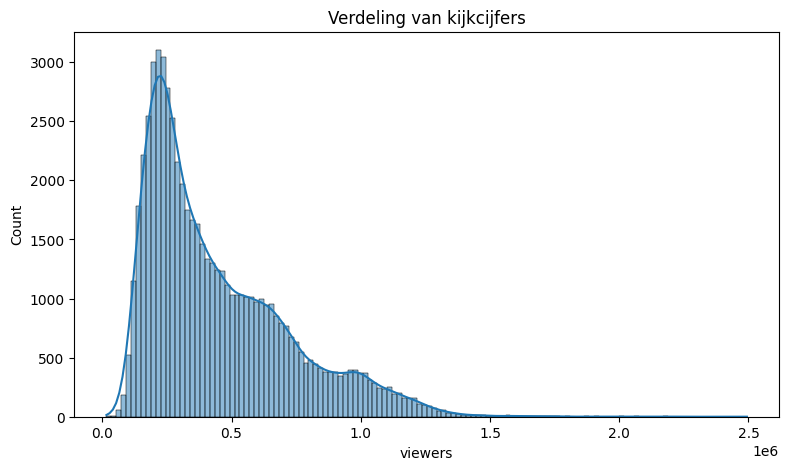

In [43]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['viewers'], kde=True)
plt.title("Verdeling van kijkcijfers")
plt.show()

Maandelijkse cijfers plotten
- Je ziet de effecten van seizoenen + effect van corona
- Steeds minder mensen kijken ook naar TV

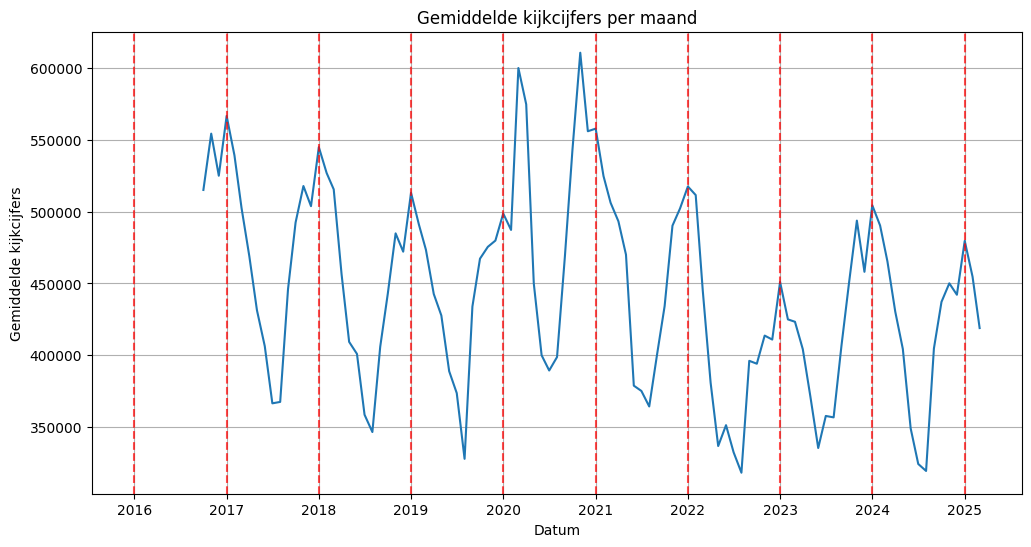

In [44]:
df_monthly = df.groupby(['year', 'month'])['viewers'].mean().reset_index()
df_monthly['date'] = pd.to_datetime(df_monthly[['year', 'month']].assign(day=1))
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='viewers', data=df_monthly)
plt.title("Gemiddelde kijkcijfers per maand")
plt.xlabel("Datum")
plt.ylabel("Gemiddelde kijkcijfers")
plt.grid(True)
jaren = df['year'].unique()

for jaar in jaren:
    plt.axvline(pd.Timestamp(f'{jaar}-01-01'), color='red', linestyle='--', alpha=0.7)
plt.show()

Plot per seizoen kijkcijfers:
- Meer in winter, minder in zomer

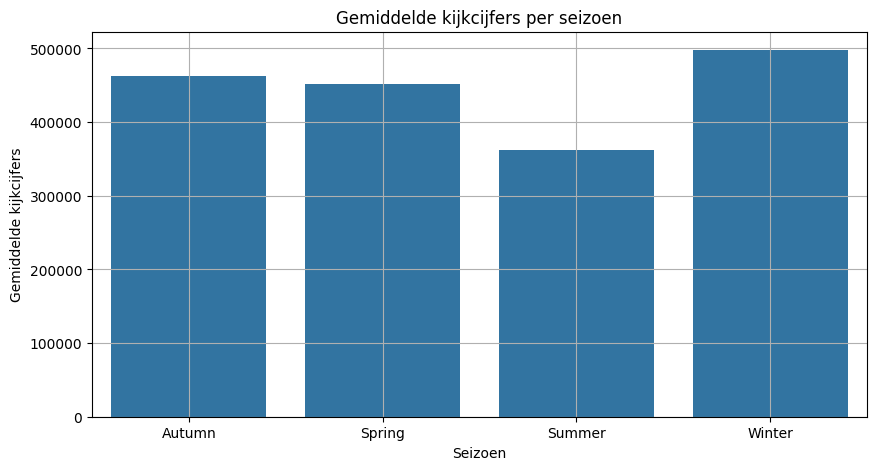

In [45]:
df['season'] = df['month'].apply(lambda x: 'Winter' if x in [12, 1, 2] else ('Spring' if x in [3, 4, 5] else ('Summer' if x in [6, 7, 8] else 'Autumn')))
df_season = df.groupby('season')['viewers'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(x='season', y='viewers', data=df_season)
plt.title("Gemiddelde kijkcijfers per seizoen")
plt.xlabel("Seizoen")
plt.ylabel("Gemiddelde kijkcijfers")
plt.grid(True)
plt.show()

Plot gemiddelde kijkcijfers per uur van de dag:
- Prime time is van 18u t.e.m. 21u

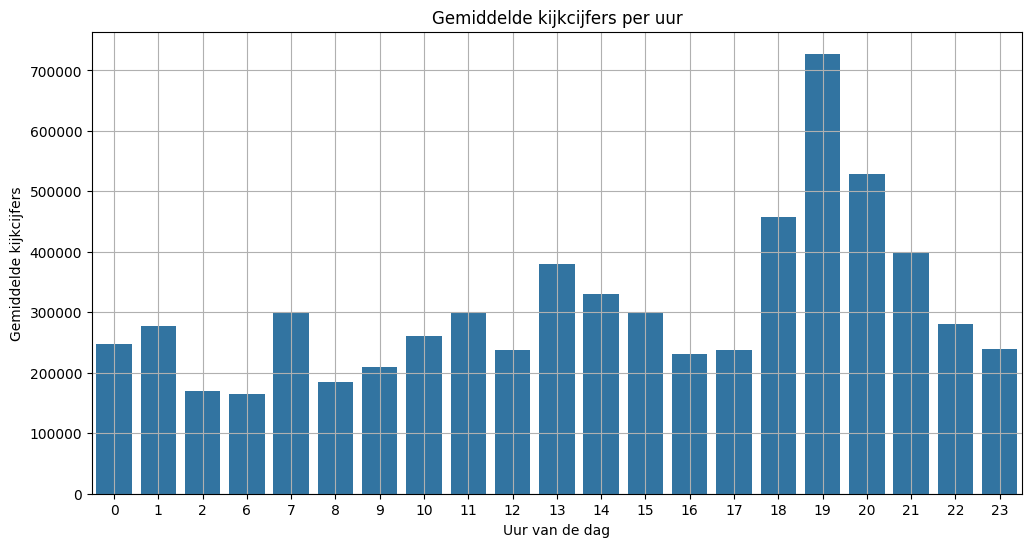

In [46]:
df_hourly = df.groupby('hour')['viewers'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='hour', y='viewers', data=df_hourly)
plt.title("Gemiddelde kijkcijfers per uur")
plt.xlabel("Uur van de dag")
plt.ylabel("Gemiddelde kijkcijfers")
plt.grid(True)
plt.show()

Check correlatie met nieuwe feature is_primetime:
- Sterke correlatie

In [47]:
df['is_primetime'] = df['hour'].apply(lambda x: 1 if x >= 18 and x <= 21 else 0)

corr = df['is_primetime'].corr(df['viewers'])
print(f"Correlatie tussen primetime en kijkcijfers: {corr:.2f}")

Correlatie tussen primetime en kijkcijfers: 0.41


Check per dag van de week
- Minder kijkers op vrijdag en zaterdag

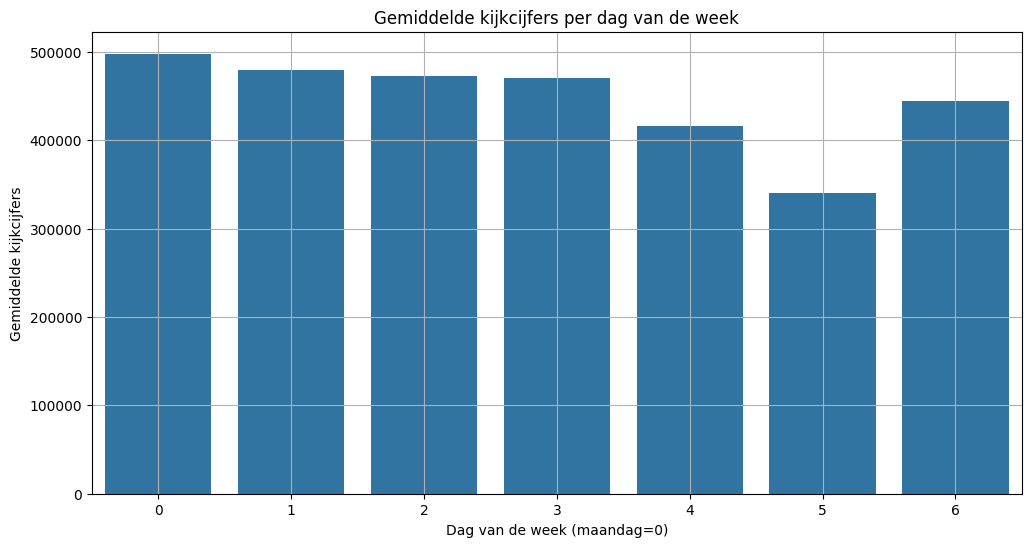

In [48]:
df_day_of_week = df.groupby('day_of_week')['viewers'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='day_of_week', y='viewers', data=df_day_of_week)
plt.title("Gemiddelde kijkcijfers per dag van de week")
plt.xlabel("Dag van de week (maandag=0)")
plt.ylabel("Gemiddelde kijkcijfers")
plt.grid(True)
plt.show()

Check correlatie nieuwe kolom, is_weekend:
- Oke correlatie

In [49]:
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x in [4, 5] else 0)

corr = df['is_weekend'].corr(df['viewers'])
print(f"Correlatie tussen weekend en kijkcijfers: {corr:.2f}")

Correlatie tussen weekend en kijkcijfers: -0.15


Impact van feestdagen op kijkcijfers:
- Geen significante correlatie

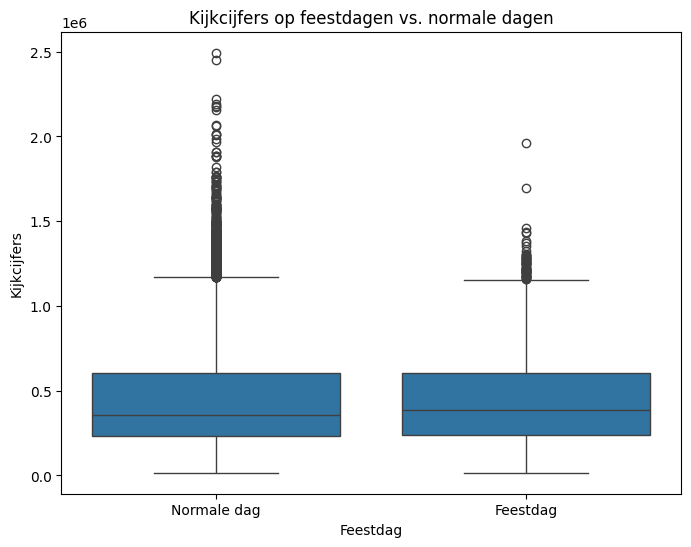

Correlatie tussen is_holiday en viewers: 0.008123952159955209


In [50]:
be_holidays = holidays.BE()
df['is_holiday'] = df['timestamp'].apply(lambda x: 1 if x in be_holidays else 0)

plt.figure(figsize=(8, 6))
sns.boxplot(x='is_holiday', y='viewers', data=df)
plt.title("Kijkcijfers op feestdagen vs. normale dagen")
plt.xlabel("Feestdag")
plt.ylabel("Kijkcijfers")
plt.xticks([0, 1], ['Normale dag', 'Feestdag'])
plt.show()

corr = df['is_holiday'].corr(df['viewers'])
print(f"Correlatie tussen is_holiday en viewers: {corr}")

Invloed van sunrise en sunset:
- Uur van sunset/sunrise (komt op zelfde neer) correleert wel oke

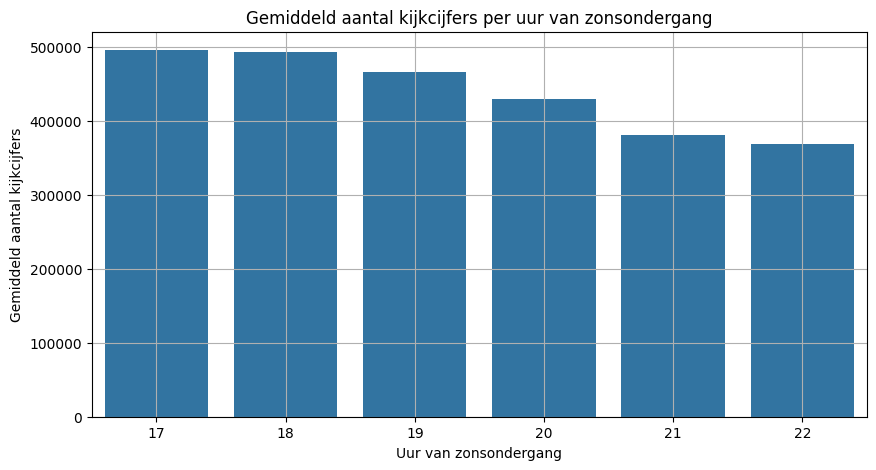

Correlatie tussen sunset_hour en viewers: -0.16558246445455038


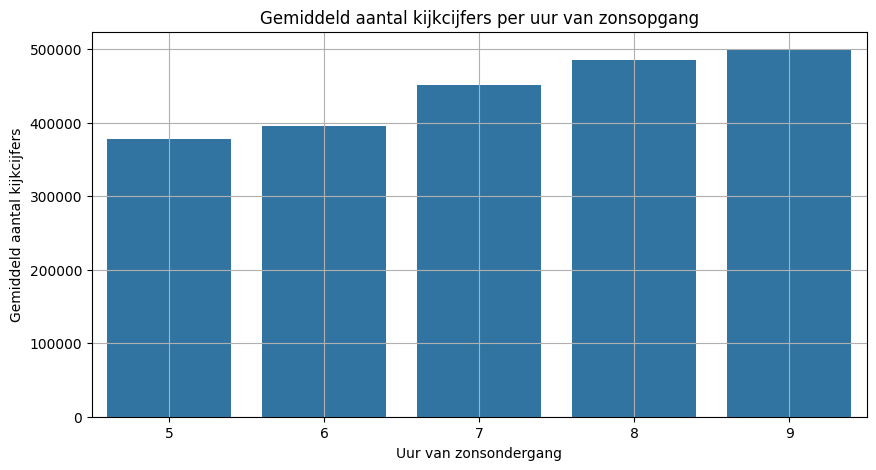

Correlatie tussen sunrise_hour en viewers: 0.1718942491785679


In [51]:
df['sunset'] = pd.to_datetime(df['sunset'])
df['sunrise'] = pd.to_datetime(df['sunrise'])

df['sunset_hour'] = df['sunset'].dt.hour
df['sunrise_hour'] = df['sunrise'].dt.hour

df_sunset_hour = df.groupby('sunset_hour')['viewers'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(x='sunset_hour', y='viewers', data=df_sunset_hour)
plt.title("Gemiddeld aantal kijkcijfers per uur van zonsondergang")
plt.xlabel("Uur van zonsondergang")
plt.ylabel("Gemiddeld aantal kijkcijfers")
plt.grid(True)
plt.show()

corr_sunset = df['sunset_hour'].corr(df['viewers'])
print(f"Correlatie tussen sunset_hour en viewers: {corr_sunset}")

df_sunrise_hour = df.groupby('sunrise_hour')['viewers'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(x='sunrise_hour', y='viewers', data=df_sunrise_hour)
plt.title("Gemiddeld aantal kijkcijfers per uur van zonsopgang")
plt.xlabel("Uur van zonsondergang")
plt.ylabel("Gemiddeld aantal kijkcijfers")
plt.grid(True)
plt.show()

corr_sunrise = df['sunrise_hour'].corr(df['viewers'])
print(f"Correlatie tussen sunrise_hour en viewers: {corr_sunrise}")

Check de correlaties tussen kijkcijfers en weer features:
- Meeste features lage correlatie
- Meest correlerend = `temperature_2m` en `daylight_duration`

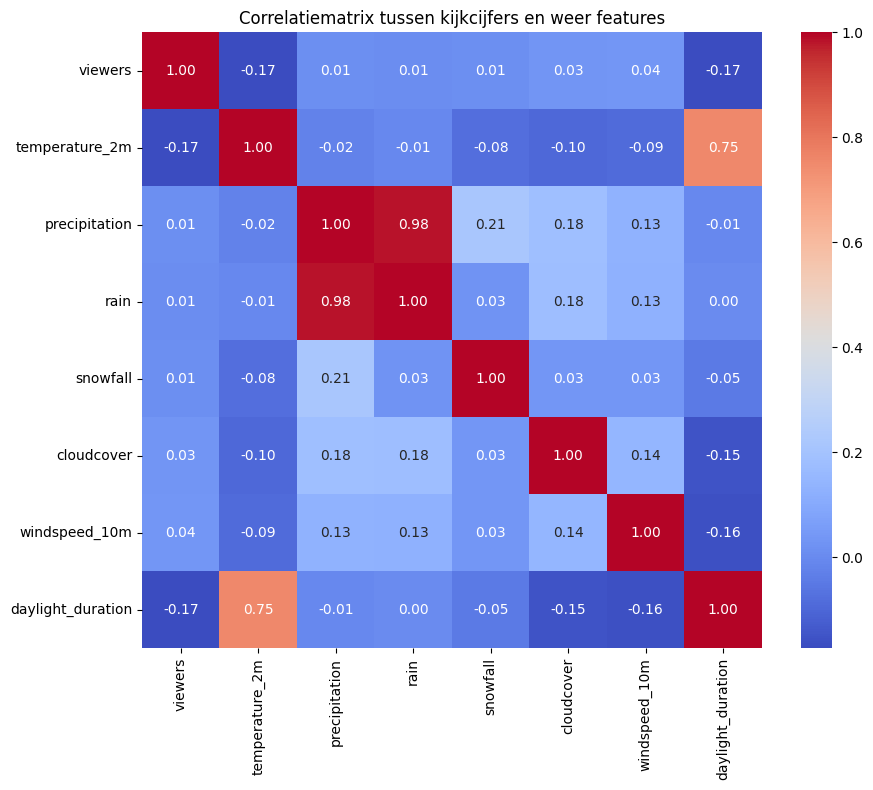

In [52]:
cols_corr = ['viewers', 'temperature_2m', 'precipitation', 'rain', 'snowfall', 
             'cloudcover', 'windspeed_10m', 'daylight_duration']
corr_matrix = df[cols_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlatiematrix tussen kijkcijfers en weer features")
plt.show()

Invloed extreme temperaturen:
- Lage temperatuur = hogere kijkcijfers (was al te zien in correlatiematrix)

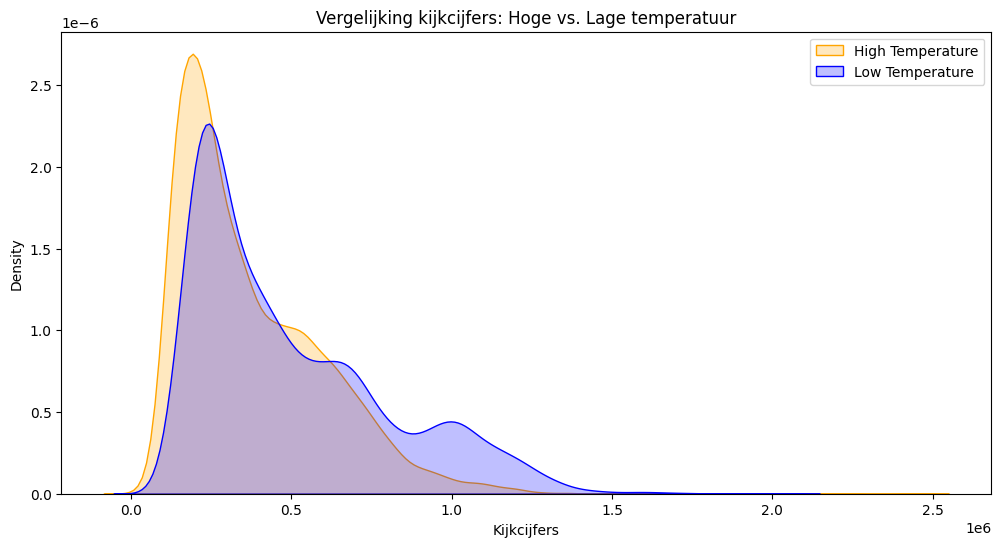

In [53]:
high_temp = df[df['temperature_2m'] > df['temperature_2m'].quantile(0.75)]
low_temp = df[df['temperature_2m'] < df['temperature_2m'].quantile(0.25)]

plt.figure(figsize=(12, 6))
sns.kdeplot(high_temp['viewers'], fill=True, label='High Temperature', color='orange')
sns.kdeplot(low_temp['viewers'], fill=True, label='Low Temperature', color='blue')
plt.title("Vergelijking kijkcijfers: Hoge vs. Lage temperatuur")
plt.xlabel("Kijkcijfers")
plt.legend()
plt.show()

Effect van weercode op kijkcijfers:
- Oke correlaties

In [57]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

encoded_array = encoder.fit_transform(df[['weather_code_daily']])

encoded_df = pd.DataFrame(encoded_array.toarray(), columns=encoder.get_feature_names_out(['weather_code_daily']))

df_encoded = pd.concat([df, encoded_df], axis=1)

columns_to_check = [col for col in df_encoded.columns if col.startswith('weather_code_daily')] + ['viewers']

corr_mx= df_encoded[columns_to_check].corr()

correlation_with_viewers = corr_mx['viewers'].abs().sort_values(ascending=False)

print(correlation_with_viewers)
correlation_sum = correlation_with_viewers.drop('viewers').sum()
print(f"Som van de correlaties: {correlation_sum:.2f}")

viewers                   1.00
weather_code_daily        0.04
weather_code_daily_73.0   0.03
weather_code_daily_3.0    0.02
weather_code_daily_55.0   0.02
weather_code_daily_71.0   0.02
weather_code_daily_75.0   0.02
weather_code_daily_61.0   0.01
weather_code_daily_53.0   0.01
weather_code_daily_1.0    0.01
weather_code_daily_65.0   0.01
weather_code_daily_63.0   0.01
weather_code_daily_2.0    0.01
weather_code_daily_0.0    0.01
weather_code_daily_51.0   0.01
Name: viewers, dtype: float64
Som van de correlaties: 0.23


# Feature Engineering

In [58]:
import pandas as pd
import numpy as np
import holidays
import pickle
from sklearn.preprocessing import OneHotEncoder
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from category_encoders import TargetEncoder
import nltk

In [59]:
kijkcijfers = pd.read_csv('./data2/processed/kijkcijfers_weerdata.csv')

Functies om bepaalde feature engineering delen eenvoudig te kunnen toepassen

In [60]:
# Hulpfunctie om seizoen te bepalen
def get_season(date):
    if date.month in [3, 4, 5]:
        return 'spring'
    elif date.month in [6, 7, 8]:
        return 'summer'
    elif date.month in [9, 10, 11]:
        return 'autumn'
    else:
        return 'winter'

# Functie om features op basis van timestamp te maken
def timestamp_feature_engineering(df):
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    df['season'] = df['timestamp'].apply(get_season)

    # weekday toevoegen
    df['weekday'] = df['timestamp'].dt.weekday

    # uur toevoegen
    df['hour'] = df['timestamp'].dt.hour

    # dag toevoegen
    df['day'] = df['timestamp'].dt.day

    # maand toevoegen
    df['month'] = df['timestamp'].dt.month

    # isWeekend toevoegen
    df['isWeekend'] = df['weekday'].apply(lambda x: 1 if x in [4, 5] else 0)

    # isPrimeTime toevoegen
    df['isPrimeTime'] = df['hour'].apply(lambda x: 1 if x >= 18 and x <= 21 else 0)

    # Sunrise en sunset hour toevoegen ipv datetime
    df['sunrise_hour'] = df['sunrise'].apply(lambda x: pd.to_datetime(x).hour)
    df['sunset_hour'] = df['sunset'].apply(lambda x: pd.to_datetime(x).hour)

    df.drop(['sunrise', 'sunset'], axis=1, inplace=True)

# Functie om lag features toe te voegen
def add_lag(df, n):
    for i in range(1, n+1):
        df[f'viewers_lag{i}'] = df.sort_values('timestamp').groupby('program')['viewers'].shift(i).ffill()
    return df

# Functie om one hot encoding toe te voegen
def category_encoding(df):
    # Categorical features
    cats = ['weather_code', 'season', 'channel', 'day_of_week']

    cat_encoder = OneHotEncoder(handle_unknown='ignore')
    df_cat = df[cats]
    one_hot = cat_encoder.fit_transform(df_cat).toarray()

    one_hot_df = pd.DataFrame(one_hot, columns=cat_encoder.get_feature_names_out(), index=df_cat.index)
    
    df = df.drop(cats + ['weather_code_daily'], axis=1)
    df = pd.concat([df, one_hot_df], axis=1)
    

    with open('./models2/one_hot_encoder.pkl', 'wb') as f:
        pickle.dump(cat_encoder, f)
    
    return df

# Functie om stopwoorden uit program naam te verwijderen
def remove_program_stopwords(df):
    nltk.download('stopwords')

    stop_words_nl = set(stopwords.words('dutch'))
    stop_words_en = set(stopwords.words('english'))
    stop_words = stop_words_nl.union(stop_words_en)

    extra_stopwoorden = {'aflevering', 'herhaling', 'van', 'het', 'de', 'with', '?', ','}
    stop_words.update(extra_stopwoorden)

    def remove_stopwords(text):
        words = text.lower().split()
        words_filtered = [word for word in words if word not in stop_words]
        return ' '.join(words_filtered)

    df['program'] = df['program'].apply(remove_stopwords)
    return df

# Functie om tf-idf vectorisatie toe te voegen
def tfidf_vectorization(df):
    vectorizer = TfidfVectorizer(max_features=100)
    tfidf_matrix = vectorizer.fit_transform(df['program'])
    
    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out(), index=df.index)
    
    df = pd.concat([df, tfidf_df], axis=1)

    with open('./models2/tfidf_vectorizer.pkl', 'wb') as f:
        pickle.dump(vectorizer, f)

    return df

# Functie om target encoding toe te voegen
def target_encoding(df, column, target):
    target_encoder = TargetEncoder(cols=[column])
    target_encoder.fit(df[column], df[target])
    df[f'{column}_target_enc'] = target_encoder.transform(df[column], df[target])
    
    # df.drop(column, axis=1, inplace=True)

    with open('./models2/target_encoder.pkl', 'wb') as f:
        pickle.dump(target_encoder, f)
    
    return df

In [61]:
# Timestamp feature engineering toepassen
timestamp_feature_engineering(kijkcijfers)

# Lag features toevoegen, en daarna lege waarden verwijderen
add_lag(kijkcijfers, 2)

kijkcijfers.dropna(inplace=True)

# One hot encoding toepassen
kijkcijfers = category_encoding(kijkcijfers)

# Stopwoorden verwijderen uit program's
remove_program_stopwords(kijkcijfers)

# TF-IDF vectorization toepassen
kijkcijfers = tfidf_vectorization(kijkcijfers)

# Target encoding toepassen
kijkcijfers = target_encoding(kijkcijfers, 'program', 'viewers')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dylan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [62]:
kijkcijfers_num = kijkcijfers.select_dtypes(include=[np.number])
corr_mx = kijkcijfers_num.corr()

print(corr_mx['viewers'].abs().sort_values(ascending=False).head(20))

viewers              1.00
program_target_enc   0.83
viewers_lag1         0.82
viewers_lag2         0.78
isPrimeTime          0.41
thuis                0.39
channel_EEN          0.33
uur                  0.24
beroemd              0.22
iedereen             0.22
daylight_duration    0.17
sunrise_hour         0.17
temperature_2m       0.17
season_summer        0.17
sunset_hour          0.17
13u                  0.16
journaal             0.16
day_of_week_5        0.16
channel_Canvas       0.15
isWeekend            0.15
Name: viewers, dtype: float64


In [63]:
kijkcijfers.to_csv('./data2/feat_eng/kijkcijfers_weerdata.csv', index=False)

print("Feature engineering completed and saved to ./data2/feat_eng/kijkcijfers_weerdata.csv")

Feature engineering completed and saved to ./data2/feat_eng/kijkcijfers_weerdata.csv


## Verder Sentence Embedding proberen toe te passen op program kolom

In [64]:
from sentence_transformers import SentenceTransformer

# Sentence Tranformer = ST
ST_model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = ST_model.encode(kijkcijfers['program'].tolist(), convert_to_tensor=False, show_progress_bar=True)

embedding_columns = [f"embedding_{i}" for i in range(embeddings.shape[1])]

df_embeddings = pd.DataFrame(embeddings, columns=embedding_columns)

kijkcijfers = pd.concat([kijkcijfers, df_embeddings], axis=1)

C:\Users\dylan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 1908/1908 [01:13<00:00, 26.12it/s]


In [65]:
kijkcijfers_num = kijkcijfers.select_dtypes(include=[np.number])
corr_mx = kijkcijfers_num.corr()

print(corr_mx['viewers'].abs().sort_values(ascending=False).head(20))

viewers              1.00
program_target_enc   0.83
viewers_lag1         0.82
viewers_lag2         0.78
isPrimeTime          0.41
thuis                0.39
channel_EEN          0.33
embedding_11         0.29
embedding_310        0.27
embedding_102        0.27
embedding_174        0.26
embedding_299        0.26
embedding_303        0.25
embedding_254        0.25
uur                  0.24
embedding_363        0.24
embedding_231        0.24
embedding_367        0.23
embedding_155        0.23
embedding_256        0.23
Name: viewers, dtype: float64


In [66]:
kijkcijfers.to_csv('./data2/feat_eng/kijkcijfers_weerdata_met_sentence_embedding.csv', index=False)